# IAA Analysis - Archaeological NER

## Metrics Calculated:
1. **Pairwise Agreement**: Global sentence-level match % and Span F1-Score.
2. **Label Breakdown**: Per-label F1-scores to identify ambiguous categories.
3. **Discrepancy Analysis**: Boundary disagreements vs. classification errors.
4. **Annotator Distribution**: Comparison of label usage density.

In [ ]:
import os
from pathlib import Path
import ast
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from datasets import load_dataset
from archaeo_ner_greek.utils import (
    prepare_iaa_data, 
    calculate_ner_iaa, 
    calculate_label_iaa, 
    analyze_iaa_discrepancies
)
from archaeo_ner_greek.logging_config import setup_logging
import logging

In [ ]:
# 1. Setup logging and environment
logger = logging.getLogger(__name__)
load_dotenv()

annotator_a = os.getenv("ANNOTATOR_A")
annotator_b = os.getenv("ANNOTATOR_B")

if not annotator_a:
    annotator_a = "stalexan"

if not annotator_b:
    annotator_b = "sasi.dimopoulou"

logger.info(f"Annotator A: {annotator_a}")
logger.info(f"Annotator B: {annotator_b}")

## 2. Data Loading from local Excel file
We load the cleaned Excel file after duplicate removal and reconstruct the Argilla responses.

In [ ]:

logger.info("Loading annotated data from local Excel file...")

# Αν το notebook βρίσκεται στον φάκελο notebooks και το Excel είναι στον ίδιο φάκελο
excel_path = Path.cwd() / "ArchaeoNER_Round_1_Final_no_duplicates.xlsx"

df = pd.read_excel(
    excel_path,
    sheet_name="Annotated_Data",
    engine="openpyxl"
)

logger.info(f"Loaded {len(df)} records from Excel.")
logger.info(f"Available columns: {df.columns.tolist()}")


def parse_excel_responses(value):
    """
    Converts the Excel string representation of Argilla responses
    back into a Python list of dictionaries.
    """

    if isinstance(value, list):
        responses = value

    elif pd.isna(value):
        return []

    elif isinstance(value, str):
        cleaned = re.sub(
            r"<ResponseStatus\.submitted: 'submitted'>",
            "'submitted'",
            value
        )

        responses = ast.literal_eval(cleaned)

    else:
        return []

    # Keep only actual span annotations.
    # This removes comment-only responses such as "ok", "ΟΚ", "οκ".
    annotation_responses = [
        response for response in responses
        if isinstance(response, dict)
        and isinstance(response.get("values"), list)
    ]

    return annotation_responses


df["responses"] = df["responses"].apply(parse_excel_responses)

logger.info("Converted Excel responses to Python objects.")
logger.info(f"Loaded {len(df)} cleaned records ready for IAA.")

## 3. Structuring Data for IAA
We transform the raw responses into (start, end, label) triplets.

In [4]:
# Prepare data for agreement analysis
iaa_results = prepare_iaa_data(df)
iaa_ready = iaa_results["ready"]

# Report annotation status
print(f"\n--- Annotation Status ---")
print(f"✅ Sentences ready for IAA (2+ annotators): {len(iaa_ready)}")
print(f"⚠️  Missing teammates (only 1 annotator): {len(iaa_results['missing_teammate'])}")
print(f"❌ Unannotated sentences: {len(iaa_results['unannotated'])}")


--- Annotation Status ---
✅ Sentences ready for IAA (2+ annotators): 195
⚠️  Missing teammates (only 1 annotator): 129
❌ Unannotated sentences: 0


## 4. Global Pairwise Agreement
Calculating high-level consistency metrics.

In [5]:
print(f"\n--- Global Agreement Report ---")
iaa_report = calculate_ner_iaa(iaa_ready)
print(iaa_report.to_string(index=False))


--- Global Agreement Report ---
            Annotator Pair  Sentences Compared  Perfect Matches Sentence Match %  Span F1-Score
sasi.dimopoulou ↔ stalexan                 195              151            77.4%         0.9113


## 5. Per-Label Agreement Breakdown
Identifying which entity types cause the most confusion.

In [6]:
print(f"\n--- Per-Label Agreement Breakdown ---")
label_report = calculate_label_iaa(iaa_ready, annotators=[annotator_a, annotator_b])
print(label_report.to_string(index=False))


--- Per-Label Agreement Breakdown ---
   Label  Both  Only in A (stalexan)  Only in B (sasi.dimopoulou)  F1-Score
LOCATION    41                     2                            2    0.9535
MATERIAL    74                     4                            5    0.9427
 CONTEXT   208                    18                           16    0.9244
  PERSON    24                     3                            1    0.9231
  PERIOD    73                     7                            7    0.9125
 FEATURE    72                     9                            7    0.9000
ARTEFACT   154                    19                           23    0.8800
 SPECIES    17                     2                            4    0.8500
 OVERALL   663                    64                           65    0.9113


## 6. Discrepancy Analysis
Quantifying boundary vs. classification errors.

In [7]:
print(f"\n--- Discrepancy Analysis ---")
discrepancy_report = analyze_iaa_discrepancies(iaa_ready, annotators=[annotator_a, annotator_b])
print(discrepancy_report)


--- Discrepancy Analysis ---
                           Count
Exact Matches             663.00
Label Mismatches            4.00
Boundary Disagreements     55.00
Total Misses (A only)       5.00
Total Misses (B only)       9.00
Boundary Char Diff (Avg)    4.75


## 7. Visualizations & Final Reporting

C:\Users\Σταυρούλα\AppData\Local\Temp\ipykernel_24348\1541458829.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=label_data_clean, x="F1-Score", y="Label", ax=axes[0], palette="viridis")
C:\Users\Σταυρούλα\AppData\Local\Temp\ipykernel_24348\1541458829.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=discrepancy_data, x="Count", y="Error Type", ax=axes[2], palette="rocket")


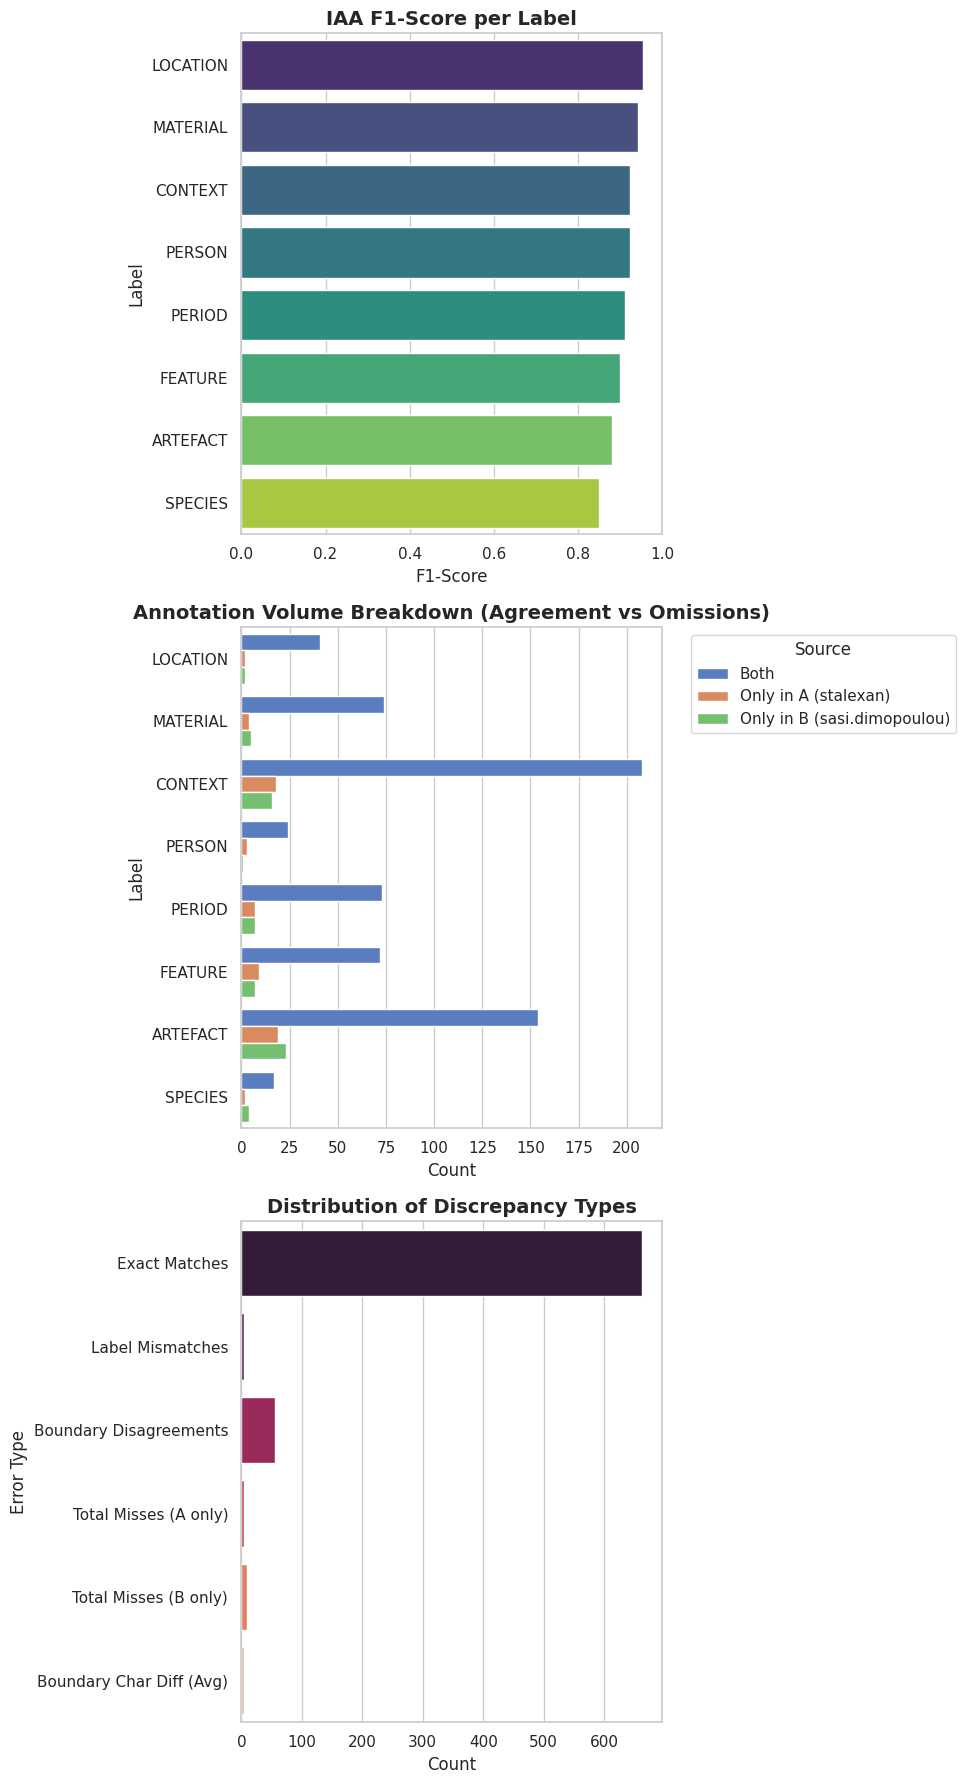


--- FINAL TABLES ---

[GLOBAL AGREEMENT]
            Annotator Pair  Sentences Compared  Perfect Matches Sentence Match %  Span F1-Score
sasi.dimopoulou ↔ stalexan                 195              151            77.4%         0.9113

[LABEL BREAKDOWN]
   Label  Both  Only in A (stalexan)  Only in B (sasi.dimopoulou)  F1-Score
LOCATION    41                     2                            2    0.9535
MATERIAL    74                     4                            5    0.9427
 CONTEXT   208                    18                           16    0.9244
  PERSON    24                     3                            1    0.9231
  PERIOD    73                     7                            7    0.9125
 FEATURE    72                     9                            7    0.9000
ARTEFACT   154                    19                           23    0.8800
 SPECIES    17                     2                            4    0.8500
 OVERALL   663                    64                           

In [8]:
# 1. Set display options for better inspection
pd.set_option('display.max_colwidth', None)

# 2. Visualization Dashboard
def plot_iaa_dashboard(label_report, discrepancy_report, annotator_a, annotator_b):
    # Set visual style
    sns.set_theme(style="whitegrid")
    plt.rcParams['font.family'] = 'DejaVu Sans'
    
    fig, axes = plt.subplots(3, 1, figsize=(10, 18))
    
    # --- Panel 1: Label F1-Scores ---
    label_data_clean = label_report[label_report["Label"] != "OVERALL"].sort_values("F1-Score", ascending=False)
    sns.barplot(data=label_data_clean, x="F1-Score", y="Label", ax=axes[0], palette="viridis")
    axes[0].set_title("IAA F1-Score per Label", fontsize=14, fontweight='bold')
    axes[0].set_xlim(0, 1)
    
    # --- Panel 2: Agreement vs Disagreement Volume ---
    # Prepare data for grouped bar chart
    col_a = f"Only in A ({annotator_a})"
    col_b = f"Only in B ({annotator_b})"
    label_counts = label_data_clean.melt(
        id_vars="Label", 
        value_vars=["Both", col_a, col_b], 
        var_name="Category", 
        value_name="Count"
    )
    sns.barplot(data=label_counts, x="Count", y="Label", hue="Category", ax=axes[1], palette="muted")
    axes[1].set_title("Annotation Volume Breakdown (Agreement vs Omissions)", fontsize=14, fontweight='bold')
    axes[1].legend(title="Source", bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # --- Panel 3: Discrepancy Types Distribution ---
    discrepancy_data = discrepancy_report.reset_index()
    discrepancy_data.columns = ["Error Type", "Count"]
    sns.barplot(data=discrepancy_data, x="Count", y="Error Type", ax=axes[2], palette="rocket")
    axes[2].set_title("Distribution of Discrepancy Types", fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# 3. Execution
if len(iaa_ready) > 0:
    plot_iaa_dashboard(label_report, discrepancy_report, annotator_a, annotator_b)
    
    print("\n--- FINAL TABLES ---")
    print("\n[GLOBAL AGREEMENT]")
    print(iaa_report.to_string(index=False))
    print("\n[LABEL BREAKDOWN]")
    print(label_report.to_string(index=False))
    print("\n[DISCREPANCY SUMMARY]")
    print(discrepancy_report)
else:
    print("No data ready for visualization.")

## 8. Export to LaTeX
Generates thesis-ready tables if EXPORT_LATEX_TABLES is enabled.

In [9]:
if os.getenv("EXPORT_LATEX_TABLES", "False").lower() == "true":
    from archaeo_ner_greek.utils import export_to_latex_table
    
    # 1. Overall Results
    export_to_latex_table(
        iaa_report, 
        caption="Overall IΑΑ results.", 
        label="tab:iaa-overall"
    )
    
    # 2. Label Breakdown
    export_to_latex_table(
        label_report, 
        caption="IΑΑ results per entity label.", 
        label="tab:iaa-label-breakdown"
    )
    
    # 3. Discrepancy Summary
    export_to_latex_table(
        discrepancy_report.reset_index(), 
        caption="Distribution of annotation discrepancy types.", 
        label="tab:iaa-discrepancies"
    )


--- LaTeX Table: tab:iaa-overall ---

\begin{table}[htbp]
\centering
\small
\begin{tabular}{lrrlr}
\toprule
 Annotator Pair                                &   Sentences Compared &   Perfect Matches & Sentence Match \\%   &   Span F1-Score \\
\midrule
 sasi.dimopoulou PLACEHOLDER\_LR\_ARROW stalexan &                  195 &               151 & 77.4\\%              &          0.9113 \\
\bottomrule
\end{tabular}
\caption{Overall IΑΑ results.}
\label{tab:iaa-overall}
\end{table}

---------------------------


--- LaTeX Table: tab:iaa-label-breakdown ---

\begin{table}[htbp]
\centering
\small
\begin{tabular}{lrrrr}
\toprule
 Label    &   Both &   Only in A (stalexan) &   Only in B (sasi.dimopoulou) &   F1-Score \\
\midrule
 LOCATION &     41 &                      2 &                             2 &     0.9535 \\
 MATERIAL &     74 &                      4 &                             5 &     0.9427 \\
 CONTEXT  &    208 &                     18 &                            16 &     0.924